# Import Library

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Data Load

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?id=1V2IdrRQ8XQmJlzb2PAlJw0ziJQg-13QW')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


# Data Preprocessing

In [ ]:
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [ ]:
df['Description'] = df['Description'].fillna("Tidak ada deskripsi")
df = df.dropna(subset=['Customer ID'])
df['Customer ID'] = df['Customer ID'].astype(str)
print(df.isnull().sum())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [ ]:
print(df.duplicated().sum())

26479


In [ ]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [ ]:
df.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,779425,779425,779425,779425.000000,779425,779425.000000,779425,779425
unique,36969,4631,5283,NaN,NaN,NaN,5878,41
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,17841.0,United Kingdom
freq,542,5023,5016,NaN,NaN,NaN,12435,700388
mean,NaN,NaN,NaN,13.489370,2011-01-03 01:44:42.593475584,3.218488,NaN,NaN
min,NaN,NaN,NaN,1.000000,2009-12-01 07:45:00,0.001000,NaN,NaN
25%,NaN,NaN,NaN,2.000000,2010-07-02 14:39:00,1.250000,NaN,NaN
50%,NaN,NaN,NaN,6.000000,2010-12-02 14:09:00,1.950000,NaN,NaN
75%,NaN,NaN,NaN,12.000000,2011-08-01 13:44:00,3.750000,NaN,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,10953.500000,NaN,NaN


In [ ]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Quantity'] >= Q1 - 1.5*IQR) & (df['Quantity'] <= Q3 + 1.5*IQR)]


In [ ]:
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
Index: 728306 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      728306 non-null  object        
 1   StockCode    728306 non-null  object        
 2   Description  728306 non-null  object        
 3   Quantity     728306 non-null  int64         
 4   InvoiceDate  728306 non-null  datetime64[ns]
 5   Price        728306 non-null  float64       
 6   Customer ID  728306 non-null  object        
 7   Country      728306 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 50.0+ MB
None
            Quantity                    InvoiceDate          Price
count  728306.000000                         728306  728306.000000
mean        6.972280  2011-01-03 11:39:38.342839296       3.342766
min         1.000000            2009-12-01 07:45:00       0.001000
25%         2.000000            2010-07

In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
print(missing_values)
print(missing_percentage)

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64
Invoice        0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
Price          0.0
Customer ID    0.0
Country        0.0
dtype: float64


In [ ]:
print(df['Price'].describe())
df = df[df['Price'] > 0]

count    728306.000000
mean          3.342766
std          30.684209
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max       10953.500000
Name: Price, dtype: float64


# Data Visualisasi

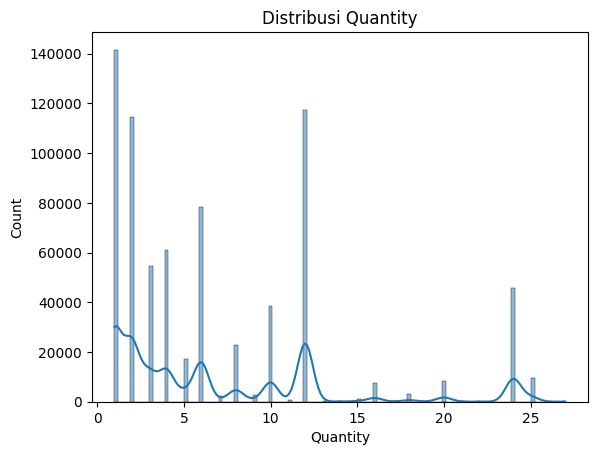

In [ ]:
sns.histplot(df['Quantity'], kde=True)
plt.title('Distribusi Quantity')
plt.show()

Distribusi Quantity pada diagram tampak right-skewed, dengan sebagian besar transaksi berada pada jumlah kecil (terutama 1–3 unit), sementara beberapa puncak jelas muncul pada nilai seperti 6, 12, dan 24 yang menunjukkan pola pembelian dalam paket standar. Nilai Quantity besar relatif jarang, sehingga distribusinya tetap wajar dan mencerminkan karakteristik umum transaksi retail, mayoritas pelanggan membeli sedikit, dan sebagian produk dijual dalam kelipatan tertentu.

In [ ]:
df ['Price']

,Price
0,6.95
1,6.75
2,6.75
4,1.25
5,1.65
...,...
1067366,2.10
1067367,4.15
1067368,4.15
1067369,4.95


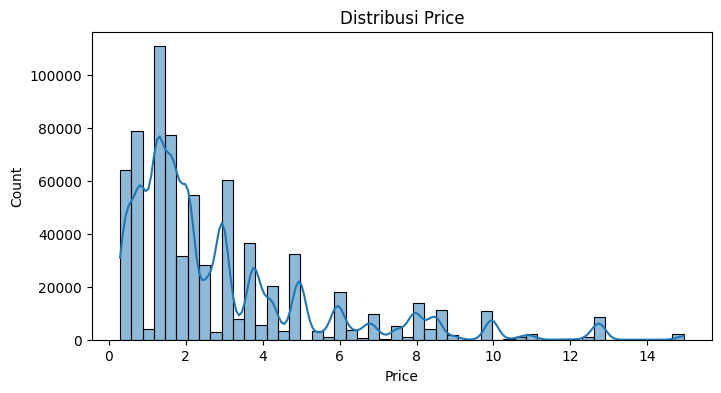

In [ ]:
p1 = df['Price'].quantile(0.01)
p99 = df['Price'].quantile(0.99)

df_no_outliers = df[(df['Price'] >= p1) & (df['Price'] <= p99)]

plt.figure(figsize=(8,4))
sns.histplot(df_no_outliers['Price'], kde=True, bins=50)
plt.title('Distribusi Price')
plt.show()


Distribusi Price setelah pembersihan menunjukkan pola right-skewed, di mana sebagian besar harga terkonsentrasi pada rentang sekitar 0.5–4 dengan puncak tertinggi di kisaran 1–2. Setelah itu frekuensi menurun tajam, hanya terlihat beberapa puncak kecil di sekitar harga 4–8, sedangkan harga di atas kisaran tersebut (mendekati 10–15) muncul sangat jarang. Pola ini menunjukkan bahwa mayoritas produk yang terjual berharga murah hingga menengah, sementara produk dengan harga tinggi hanya menyumbang sebagian kecil dari transaksi.

In [ ]:
df['Country'].value_counts().head(10)

,count
Country,
United Kingdom,659140
Germany,15350
EIRE,13850
France,12557
Spain,3476
Belgium,2927
Switzerland,2630
Netherlands,2225
Portugal,2197


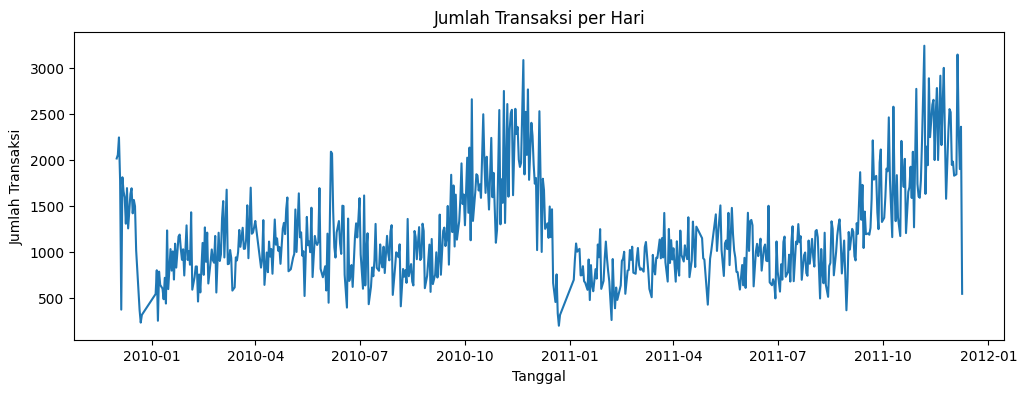

In [ ]:
df['InvoiceDate_only'] = df['InvoiceDate'].dt.date

trans_per_day = df.groupby('InvoiceDate_only').size()

plt.figure(figsize=(12,4))
trans_per_day.plot()
plt.title('Jumlah Transaksi per Hari')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Transaksi')
plt.show()


Jumlah transaksi per hari menunjukkan pola yang sangat fluktuatif dengan kecenderungan meningkat dari awal 2010 hingga akhir 2011. Pada awal periode, transaksi harian berada di kisaran 500–1500, kemudian mengalami kenaikan signifikan pada akhir 2010 dengan puncak mendekati 3000 transaksi per hari. Setelah sedikit penurunan di awal 2011, jumlah transaksi kembali meningkat menuju akhir tahun dan mencapai level tertinggi menjelang Desember 2011. Pola ini mencerminkan dinamika musim belanja dan pertumbuhan aktivitas penjualan dari waktu ke waktu.

In [ ]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

,Quantity
Description,
WHITE HANGING HEART T-LIGHT HOLDER,27542
ASSORTED COLOUR BIRD ORNAMENT,26297
60 TEATIME FAIRY CAKE CASES,23087
PACK OF 60 PINK PAISLEY CAKE CASES,20499
JUMBO BAG RED RETROSPOT,19238
PACK OF 72 RETROSPOT CAKE CASES,18453
PACK OF 72 RETRO SPOT CAKE CASES,16913
STRAWBERRY CERAMIC TRINKET BOX,16466
REGENCY CAKESTAND 3 TIER,14481


Produk dengan jumlah penjualan tertinggi didominasi oleh barang-barang dekoratif dan kebutuhan rumah tangga kecil, dengan WHITE HANGING HEART T-LIGHT HOLDER menjadi produk paling laris dengan 27.542 unit terjual. Disusul oleh ASSORTED COLOUR BIRD ORNAMENT serta berbagai jenis cake cases yang secara konsisten muncul dalam daftar teratas, menandakan tingginya permintaan untuk perlengkapan baking dan barang dekoratif murah. Produk seperti JUMBO BAG RED RETROSPOT, STRAWBERRY CERAMIC TRINKET BOX, hingga REGENCY CAKESTAND 3 TIER juga menunjukkan volume penjualan besar, mencerminkan bahwa pelanggan cenderung membeli barang-barang hadiah, dekorasi, dan perlengkapan rumah dengan harga terjangkau dalam jumlah tinggi.

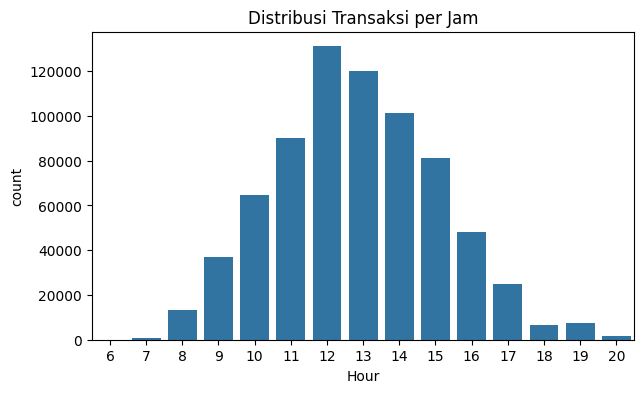

In [ ]:
df['Hour'] = df['InvoiceDate'].dt.hour

plt.figure(figsize=(7,4))
sns.countplot(x='Hour', data=df)
plt.title('Distribusi Transaksi per Jam')
plt.show()


Distribusi transaksi per jam menunjukkan bahwa aktivitas penjualan mencapai puncaknya pada jam kerja tengah hari, khususnya antara pukul 11.00 hingga 14.00, dengan lonjakan tertinggi sekitar pukul 12.00. Sebaliknya, jumlah transaksi sangat rendah pada pagi awal dan sore menjelang malam. Pola ini mengindikasikan bahwa pelanggan cenderung melakukan pemesanan pada periode sibuk kerja atau saat istirahat siang, sehingga transaksi menumpuk di sekitar jam-jam tersebut.

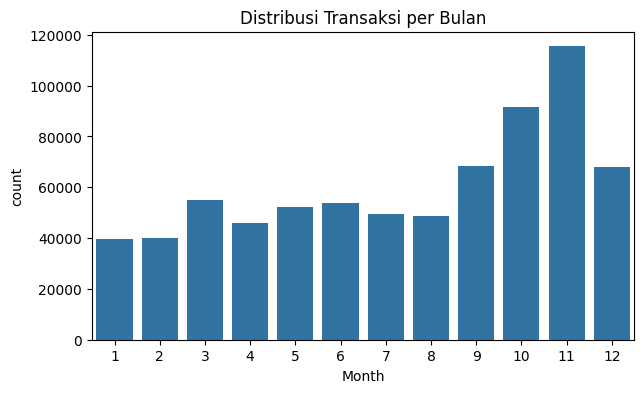

In [ ]:
df['Month'] = df['InvoiceDate'].dt.month

plt.figure(figsize=(7,4))
sns.countplot(x='Month', data=df)
plt.title('Distribusi Transaksi per Bulan')
plt.show()


Distribusi transaksi per bulan memperlihatkan pola musiman yang kuat, di mana transaksi relatif stabil dari bulan Januari hingga Agustus, kemudian mulai meningkat signifikan pada bulan September hingga November, dengan puncak tertinggi pada November. Kenaikan ini mencerminkan periode belanja musiman seperti persiapan liburan dan akhir tahun, yang biasanya mendorong aktivitas pembelian lebih tinggi. Setelah puncak tersebut, transaksi kembali menurun pada Desember, meski masih berada di atas rata-rata bulanan.

# Penerapan Model RFM

In [ ]:
latest_date = df['InvoiceDate'].max()
df['Recency'] = (latest_date - df['InvoiceDate']).dt.days

In [ ]:
frequency_df = df.groupby('Customer ID')['InvoiceDate'].nunique().reset_index()
frequency_df.columns = ['Customer ID', 'Frequency']

In [ ]:
monetary_df = df.groupby('Customer ID')['Price'].sum().reset_index()
monetary_df.columns = ['Customer ID', 'Monetary']

In [ ]:
rfm_df = pd.merge(frequency_df, monetary_df, on='Customer ID')
rfm_df = pd.merge(rfm_df, df[['Customer ID', 'Recency']].drop_duplicates(), on='Customer ID')

In [ ]:
def remove_outlier_IQR(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_clean = df[(df[column] >= lower_limit) & (df[column] <= upper_limit)]
    return df_clean
rfm_df = remove_outlier_IQR(rfm_df, 'Recency')
rfm_df = remove_outlier_IQR(rfm_df, 'Frequency')
rfm_df = remove_outlier_IQR(rfm_df, 'Monetary')

In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']])


# Penerapan Elbow Method

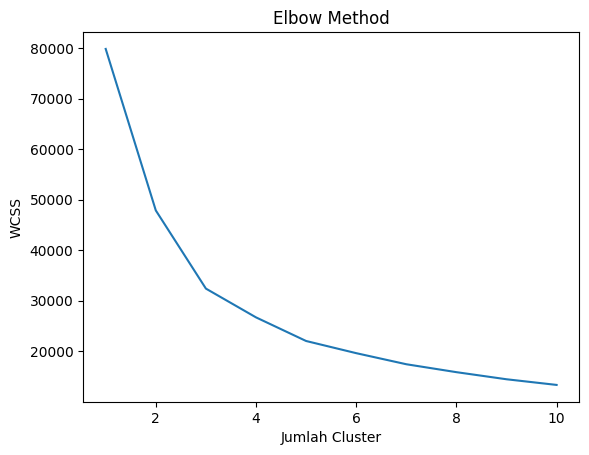

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled)
print(f"Inertia: {kmeans.inertia_}")
sil_score = silhouette_score(rfm_scaled, kmeans.labels_)
print(f"Silhouette Score: {sil_score}")

Inertia: 32406.22875843047
Silhouette Score: 0.37745047675974436


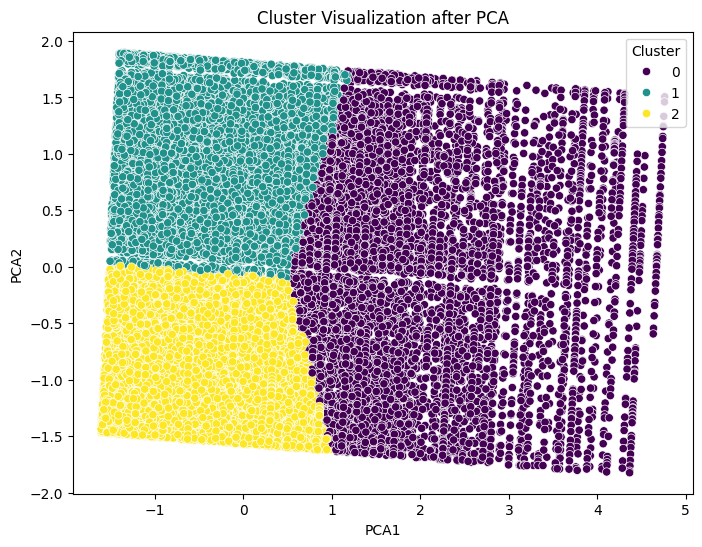

In [ ]:

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(rfm_scaled)
rfm_df['PCA1'] = pca_components[:, 0]
rfm_df['PCA2'] = pca_components[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=rfm_df, palette='viridis')
plt.title('Cluster Visualization after PCA')
plt.show()


In [ ]:
print(f'Explained Variance Ratio for PCA Components: {pca.explained_variance_ratio_}')
print(f'Total Explained Variance: {sum(pca.explained_variance_ratio_)}')

Explained Variance Ratio for PCA Components: [0.57060258 0.3324299 ]
Total Explained Variance: 0.9030324815384982


Visualisasi cluster setelah PCA menunjukkan pemisahan yang jelas antara tiga kelompok pelanggan, dengan masing-masing cluster menempati area berbeda pada ruang PCA1 dan PCA2. Cluster ungu merupakan kelompok terbesar, mencakup pelanggan dengan karakteristik RFM yang lebih umum, sementara cluster kuning dan hijau berada di posisi yang berbeda dan lebih terfokus. Hal ini menandakan segmentasi pelanggan berdasarkan pola perilaku yang cukup berbeda, seperti nilai belanja, frekuensi pembelian, atau tingkat aktivitas. Dengan total explained variance sebesar 90.30%, pemisahan ini menunjukkan bahwa metode clustering berhasil mengidentifikasi tiga segmen pelanggan dengan perbedaan nyata dalam perilaku mereka.

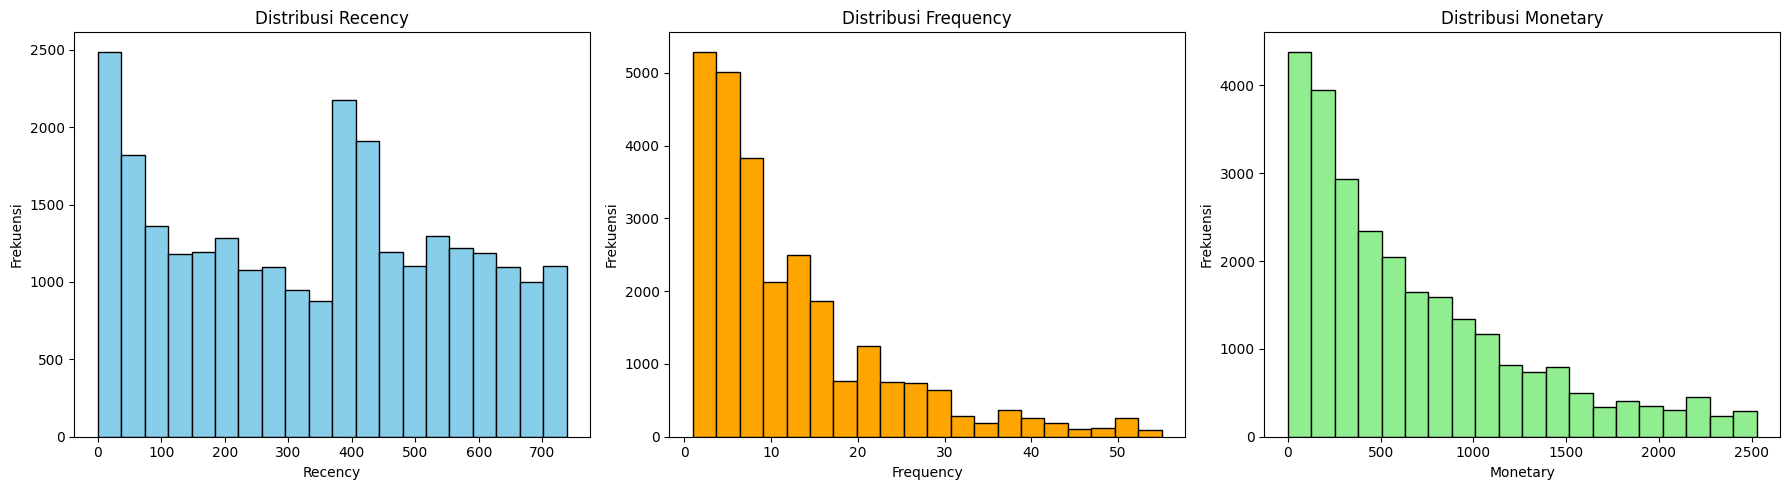

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(rfm_df['Recency'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribusi Recency')
plt.xlabel('Recency')
plt.ylabel('Frekuensi')


plt.subplot(1, 3, 2)
plt.hist(rfm_df['Frequency'], bins=20, color='orange', edgecolor='black')
plt.title('Distribusi Frequency')
plt.xlabel('Frequency')
plt.ylabel('Frekuensi')


plt.subplot(1, 3, 3)
plt.hist(rfm_df['Monetary'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribusi Monetary')
plt.xlabel('Monetary')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()


Distribusi Recency menunjukkan pola yang cukup menyebar, dengan jumlah pelanggan terbanyak berada pada rentang recency rendah hingga menengah, menandakan banyak pelanggan yang masih relatif aktif. Sementara itu, Distribusi Frequency tampak right-skewed, di mana mayoritas pelanggan bertransaksi hanya beberapa kali, sementara pelanggan dengan frekuensi tinggi jumlahnya jauh lebih sedikit. Sedangkan Distribusi Monetary juga memperlihatkan pola serupa, di mana sebagian besar pelanggan melakukan pembelian dalam nilai transaksi rendah hingga menengah, dan hanya sedikit yang memiliki total belanja tinggi. Ketiga distribusi ini menggambarkan karakteristik umum data RFM: banyak pelanggan biasa, sedikit pelanggan sangat aktif dan bernilai tinggi.

In [ ]:
 cluster_summary = rfm_df.groupby('Cluster').agg({'Recency': 'mean', 'Frequency': 'mean', 'Monetary': 'mean'})
print(cluster_summary)


            Recency  Frequency     Monetary
Cluster                                    
0        351.280138  26.615143  1508.992813
1        523.413550   7.621903   410.108475
2        130.412697   7.553502   409.595021


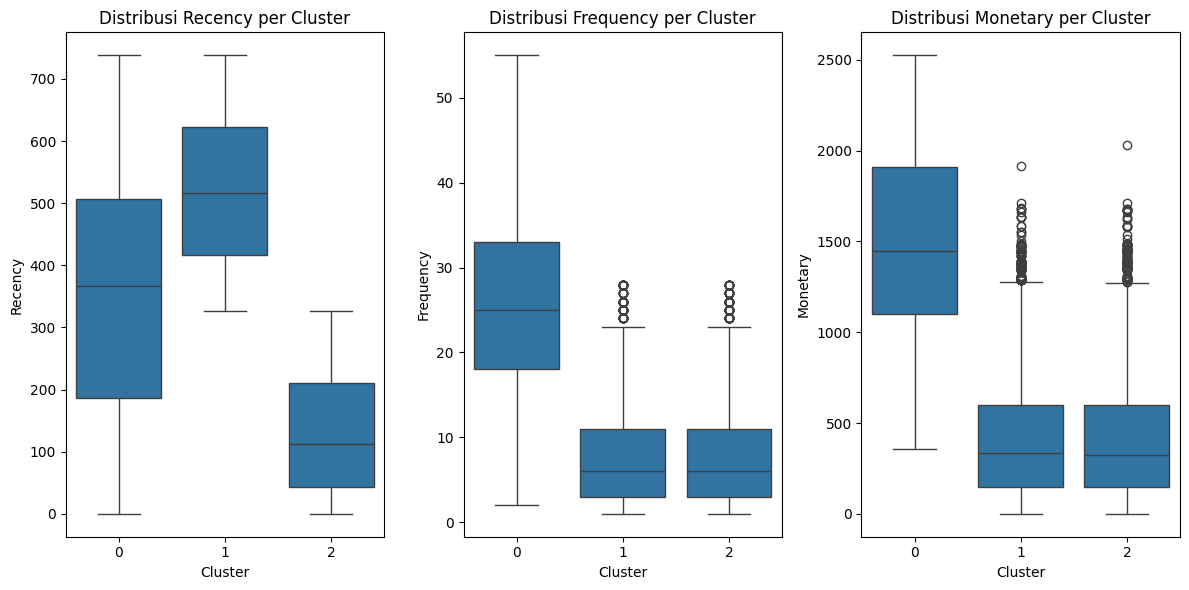

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.boxplot(x='Cluster', y='Recency', data=rfm_df)
plt.title('Distribusi Recency per Cluster')
plt.subplot(1, 3, 2)
sns.boxplot(x='Cluster', y='Frequency', data=rfm_df)
plt.title('Distribusi Frequency per Cluster')
plt.subplot(1, 3, 3)
sns.boxplot(x='Cluster', y='Monetary', data=rfm_df)
plt.title('Distribusi Monetary per Cluster')
plt.tight_layout()
plt.show()


Distribusi RFM per cluster menunjukkan perbedaan karakteristik pelanggan yang cukup jelas. Cluster 0 memiliki nilai Recency lebih tinggi (kurang aktif), tetapi Frequency dan Monetary lebih besar, menandakan pelanggan berharga tinggi namun sudah lama tidak bertransaksi. Cluster 1 memiliki Recency paling tinggi dan nilai Frequency serta Monetary rendah, menandakan pelanggan paling tidak aktif dan dengan nilai belanja kecil. Sementara itu, Cluster 2 adalah kelompok dengan Recency terendah (paling baru/aktif), namun memiliki Frequency dan Monetary menengah. Pola ini menunjukkan bahwa setiap cluster mewakili tahap perilaku pelanggan yang berbeda, dari pelanggan berpotensi kembali hingga pelanggan yang mulai tidak aktif.

In [ ]:
recency_median = rfm_df['Recency'].median()
frequency_median = rfm_df['Frequency'].median()
monetary_median = rfm_df['Monetary'].median()

def categorize_segment(row):
    if row['Frequency'] > frequency_median and row['Monetary'] > monetary_median and row['Recency'] <= recency_median:
        return 'Champions'
    elif row['Frequency'] > frequency_median and row['Recency'] <= recency_median:
        return 'Loyalists'
    elif row['Frequency'] <= frequency_median and row['Monetary'] > monetary_median:
        return 'Big spenders, low frequency'
    elif row['Recency'] <= recency_median and row['Frequency'] <= frequency_median and row['Monetary'] <= monetary_median:
        return 'New but promising'
    elif row['Recency'] > recency_median:
        return 'At-risk'
    else:
        return 'Low-value, low-engagement'
rfm_df['Segment'] = rfm_df.apply(categorize_segment, axis=1)

output_df = rfm_df[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']] \
                .drop_duplicates(subset='Customer ID', keep='first')

print(output_df.head())

   Customer ID  Recency  Frequency  Monetary  Cluster  \
0      12346.0      725         11    206.36        1   
7      12347.0      403          8    542.34        1   
15     12348.0      437          5    178.29        1   
20     12349.0      588          4   1477.09        1   
24     12350.0      309          1     65.30        2   

                        Segment  
0                       At-risk  
7   Big spenders, low frequency  
15                      At-risk  
20  Big spenders, low frequency  
24            New but promising  


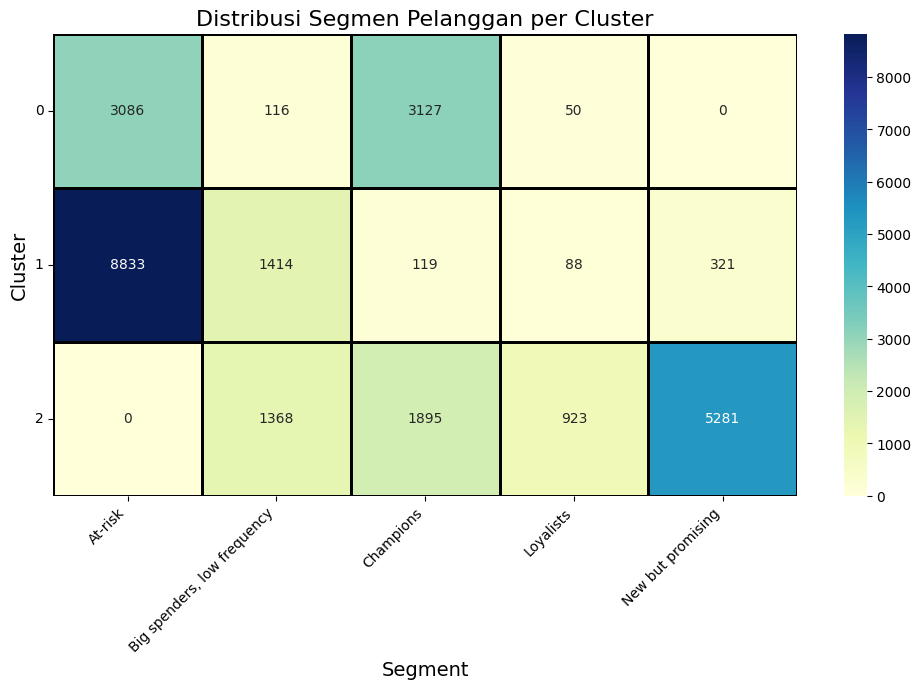

In [ ]:
segment_counts = rfm_df.pivot_table(index='Cluster', columns='Segment',
                                    aggfunc='size', fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(segment_counts, annot=True, cmap="YlGnBu", fmt="g",
            cbar=True, linewidths=1, linecolor='black')

plt.title('Distribusi Segmen Pelanggan per Cluster', fontsize=16)
plt.ylabel('Cluster', fontsize=14)
plt.xlabel('Segment', fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

**Interpretasi Hasil Clustering RFM**

Berdasarkan distribusi Recency, Frequency, dan Monetary pada kedua cluster, dapat disimpulkan bahwa:

Cluster 0
- At-risk: Terdapat 3.086 pelanggan yang masuk kategori ini, menunjukkan cukup banyak pelanggan yang berisiko churn.
- Big Spenders, Low Frequency: Hanya 116 pelanggan berada dalam segmen ini.
- Champions: Ada 3.127 pelanggan, menjadikan segmen ini salah satu yang paling besar dalam cluster 0.
- Loyalists: Sebanyak 50 pelanggan termasuk dalam kelompok pelanggan loyal.
- New but Promising: Tidak ada pelanggan (0) pada segmen ini untuk cluster 0.

Cluster 1
- At-risk: Segmen ini mendominasi cluster 1 dengan 8.833 pelanggan, menunjukkan bahwa cluster 1 adalah kelompok paling berisiko.
- Big Spenders, Low Frequency: Ada 1.414 pelanggan pada segmen ini.
- Champions: Hanya 119 pelanggan, jauh lebih sedikit dibanding cluster 0.
- Loyalists: Ada 88 pelanggan yang tergolong loyal.
- New but Promising: Terdapat 321 pelanggan pada segmen ini.

Cluster 2
- At-risk: Tidak ada pelanggan (0) pada segmen ini.
- Big Spenders, Low Frequency: Terdapat 1.368 pelanggan.
- Champions: Ada 1.895 pelanggan yang merupakan pelanggan bernilai tinggi.
- Loyalists: Sebanyak 923 pelanggan berada pada segmen loyal.
- New but Promising: Segmen terbesar pada cluster ini dengan 5.281 pelanggan, menunjukkan cluster ini berisi banyak pelanggan baru yang potensial untuk dikembangkan.

# Bisnis Insight

**Cluster 0**

Karakteristik utama cluster ini berisi campuran pelanggan bernilai tinggi dan pelanggan yang cukup berisiko, dengan jumlah besar di segmen At-risk dan Champions.
- At-risk (3.086 pelanggan): Banyak pelanggan dalam kelompok ini memiliki potensi churn, sehingga perlu perhatian khusus seperti reminder pembelian, email re-engagement, atau diskon khusus.
- Big Spenders, Low Frequency (116 pelanggan): Mereka mengeluarkan banyak uang namun tidak sering bertransaksi. Penawaran personal atau program yang meningkatkan frekuensi belanja bisa mendorong mereka lebih aktif.
- Champions (3.127 pelanggan): Kelompok yang sangat bernilai—mereka aktif dan memiliki Monetary tinggi. Mereka cocok diberikan reward premium, early access produk baru, atau VIP program.
- Loyalists (50 pelanggan): Pelanggan setia yang rutin membeli. Tingkatkan loyalitas mereka dengan penawaran membership atau hadiah loyalitas.
- New but Promising (0 pelanggan): Tidak ada pelanggan baru dengan potensi tinggi pada cluster ini.

Strategi untuk Cluster 0
Fokus pada retensi pelanggan bernilai tinggi seperti Champions dan Loyalists dengan program eksklusif dan pengalaman yang dipersonalisasi. Sementara itu, pelanggan At-risk perlu segera diaktifkan kembali melalui win-back campaigns, reminder pembelian, atau potongan harga. Targetkan Big Spenders dengan penawaran premium untuk meningkatkan frekuensi.

**Cluster 1**

Karakteristik utama cluster ini didominasi oleh pelanggan At-risk, dengan hanya sebagian kecil pelanggan bernilai tinggi.
- At-risk (8.833 pelanggan): Ini segmen terbesar dalam cluster, sehingga merupakan prioritas utama untuk kampanye reaktivasi. Berikan promosi yang kuat untuk mencegah churn lebih lanjut.
- Big Spenders, Low Frequency (1.414 pelanggan): Pelanggan yang jarang berbelanja tetapi mengeluarkan uang cukup banyak. Strategi upsell atau rekomendasi produk personal bisa membantu.
- Champions (119 pelanggan): Walaupun jumlahnya kecil, mereka tetap sangat berharga. Berikan pengalaman premium agar mereka tetap setia.
- Loyalists (88 pelanggan): Pelanggan dengan engagement stabil. Tawarkan loyalty reward, poin belanja, atau penawaran eksklusif.
- New but Promising (321 pelanggan): Pelanggan baru yang menunjukkan potensi. Perlu nurturing seperti welcome series email, penawaran pertama, atau edukasi produk.

Strategi untuk Cluster 1
Prioritaskan re-engagement massal, terutama untuk segmen At-risk yang sangat besar. Gunakan email marketing, promo besar, atau bundle produk untuk menarik mereka kembali. Pelanggan bernilai tinggi seperti Champions dan Big Spenders perlu dipertahankan melalui program VIP atau rekomendasi produk yang dipersonalisasi. Segmen New but Promising perlu nurturance agar berkembang menjadi pelanggan loyal.

**Cluster 2**

Karakteristik utama cluster ini memiliki banyak pelanggan yang baru berkembang dan sejumlah pelanggan bernilai tinggi.
- At-risk (0 pelanggan): Tidak ada pelanggan yang berisiko pada cluster ini.
Big Spenders, Low Frequency (1.368 pelanggan): Pelanggan bernilai besar namun dengan frekuensi rendah. Berikan insentif untuk mendorong repeat purchase.
- Champions (1.895 pelanggan): Pelanggan setia dan bernilai tinggi. Pertahankan momentum dengan reward eksklusif dan layanan premium.
- Loyalists (923 pelanggan): Pelanggan aktif yang rajin bertransaksi. Tawarkan program loyalitas lanjutan untuk memperkuat hubungan.
- New but Promising (5.281 pelanggan): Segmen terbesar dalam cluster ini. Mereka adalah pelanggan baru yang menunjukkan potensi besar dan harus di-nurture agar naik ke segmen loyal.

Strategi untuk Cluster 2
Fokus pada mendorong pertumbuhan pelanggan baru melalui edukasi produk, promo sambutan, dan program pengenalan brand. Loyalists dan Champions perlu dipertahankan melalui penghargaan eksklusif, poin loyalitas, dan pengalaman personal. Sementara itu, Big Spenders dapat diarahkan untuk meningkatkan frekuensi belanja melalui rekomendasi produk dan penawaran time-limited

Cluster 0 berisi campuran pelanggan bernilai tinggi seperti Champions dan kelompok At-risk, sehingga strategi utamanya adalah mempertahankan pelanggan terbaik sambil mengaktifkan kembali pelanggan yang mulai tidak aktif. Cluster 1 didominasi pelanggan At-risk dengan aktivitas dan nilai transaksi rendah, sehingga diperlukan promosi agresif, reminder, dan penawaran berbatas waktu untuk meningkatkan frekuensi belanja mereka. Cluster 2 memiliki banyak pelanggan baru yang potensial serta beberapa pelanggan bernilai tinggi, sehingga penting untuk melakukan nurturing melalui welcome offer dan edukasi produk agar mereka berkembang menjadi pelanggan loyal. Dengan strategi yang dipersonalisasi untuk tiap cluster, bisnis dapat meningkatkan engagement, retensi, dan nilai pembelian pelanggan secara lebih efektif.

In [ ]:
import pickle
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans.fit(rfm_scaled)

with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('kmeans_model.pkl', 'rb') as f:
    kmeans_loaded = pickle.load(f)

print(f"Inertia of loaded model: {kmeans_loaded.inertia_}")


Inertia of loaded model: 32406.22875843047


In [ ]:
import joblib
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans.fit(rfm_scaled)

joblib.dump(kmeans, 'kmeans_model.joblib')


['kmeans_model.joblib']

In [ ]:

requirements = """
spacy==3.0.0
pandas==1.3.3
numpy==1.21.2
matplotlib==3.4.3
seaborn==0.11.2
scikit-learn==1.0.2
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)


# Deployment

In [ ]:
!git clone https://github.com/ahnafzaki12/RFM-Kmeans-Clustering---A25-CS329.git
%cd RFM-Kmeans-Clustering---A25-CS329

Cloning into 'RFM-Kmeans-Clustering---A25-CS329'...
remote: Enumerating objects: 134, done.
remote: Counting objects: 100% (134/134), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 134 (delta 61), reused 49 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (134/134), 1.29 MiB | 1.95 MiB/s, done.
Resolving deltas: 100% (61/61), done.
/content/RFM-Kmeans-Clustering---A25-CS329/RFM-Kmeans-Clustering---A25-CS329


In [ ]:
!git status


On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

st.set_page_config(page_title="Customer Segmentation MATCH NOTEBOOK",
                   layout="wide")

st.title("Customer Segmentation Dashboard")

# LOAD

@st.cache_data
def load_data():
    url = "https://drive.google.com/uc?id=1V2IdrRQ8XQmJlzb2PAlJw0ziJQg-13QW"
    df = pd.read_csv(url)

    # 1. Missing values
    df["Description"] = df["Description"].fillna("Tidak ada deskripsi")
    df = df.dropna(subset=["Customer ID"])
    df["Customer ID"] = df["Customer ID"].astype(str)

    # 2. Drop duplicates
    df = df.drop_duplicates()

    # 3. Convert date
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

    # 4. Positive only
    df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

    # 5. IQR Quantity
    Q1 = df["Quantity"].quantile(0.25)
    Q3 = df["Quantity"].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df["Quantity"] >= Q1 - 1.5 * IQR) & (df["Quantity"] <= Q3 + 1.5 * IQR)]

    # 6. Price quantile 1%–99%
    p1 = df["Price"].quantile(0.01)
    p99 = df["Price"].quantile(0.99)
    df_price_clean = df[(df["Price"] >= p1) & (df["Price"] <= p99)]

    return df, df_price_clean

df, df_clean_price = load_data()

# SIDEBAR

menu = st.sidebar.radio(
    "Navigation",
    ["Dataset Overview", "EDA Visualizations", "RFM Analysis", "Clustering", "Business Insights"]
)

# PAGE 1 — DATASET OVERVIEW

if menu == "Dataset Overview":
    st.header("Dataset Preview")
    st.dataframe(df.head())
    st.subheader("Dataset Preview")
    st.markdown("""
    Dataset Online Retail II berisi seluruh transaksi dari sebuah perusahaan ritel daring yang berbasis di Inggris dan beroperasi tanpa toko fisik. Data mencakup periode 1 Desember 2009 hingga 9 Desember 2011, dengan fokus pada penjualan produk giftware (hadiah dan dekorasi) yang unik. Sebagian besar pelanggan merupakan wholesaler yang membeli dalam jumlah besar untuk kebutuhan bisnis.
    Struktur Atribut
    Dataset memiliki delapan atribut utama:
    - InvoiceNo - Nomor faktur unik untuk setiap transaksi.
    - StockCode — Kode unik untuk setiap produk.
    - Description — Nama atau deskripsi produk.
    - Quantity — Jumlah unit produk yang dibeli dalam satu transaksi.
    - InvoiceDate — Tanggal dan waktu transaksi terjadi.
    - UnitPrice — Harga satuan produk dalam Pound Sterling (£).
    - CustomerID — ID pelanggan unik (hanya muncul untuk pelanggan teridentifikasi)
    - Country — Negara tempat pelanggan berada.
    Setiap cluster memerlukan strategi berbeda untuk retensi, upselling, dan nurturing pelanggan.
    """)

# PAGE 2 — EDA VISUALIZATIONS
elif menu == "EDA Visualizations":

    tab1, tab2, tab3, tab4, tab5, tab6 = st.tabs([
        "Distribusi Quantity",
        "Distribusi Price",
        "Jumlah Transaksi per Hari",
        "Top 10 Produk",
        "Transaksi per Jam",
        "Transaksi per Bulan"
    ])

    # 1. Distribusi Quantity
    with tab1:
        st.subheader("Distribusi Quantity")
        fig = plt.figure(figsize=(8,4))
        sns.histplot(df["Quantity"], kde=True)
        st.pyplot(fig)

        st.markdown("""
        ### Intrepretasi Distribusi Quantity
          Distribusi Quantity pada diagram tampak right-skewed, dengan sebagian besar transaksi berada pada jumlah kecil (terutama 1–3 unit), sementara beberapa puncak jelas muncul pada nilai seperti 6, 12, dan 24 yang menunjukkan pola pembelian dalam paket standar. Nilai Quantity besar relatif jarang, sehingga distribusinya tetap wajar dan mencerminkan karakteristik umum transaksi retail, mayoritas pelanggan membeli sedikit, dan sebagian produk dijual dalam kelipatan tertentu.
        """)

    # 2. Distribusi Price cleaned
    with tab2:
        st.subheader("Distribusi Price (1%–99%)")
        fig = plt.figure(figsize=(8,4))
        sns.histplot(df_clean_price["Price"], kde=True, bins=50)
        st.pyplot(fig)

        st.markdown("""
        ### Intrepretasi Distribusi Price
          Distribusi Price setelah pembersihan menunjukkan pola right-skewed, di mana sebagian besar harga terkonsentrasi pada rentang sekitar 0.5–4 dengan puncak tertinggi di kisaran 1–2. Setelah itu frekuensi menurun tajam, hanya terlihat beberapa puncak kecil di sekitar harga 4–8, sedangkan harga di atas kisaran tersebut (mendekati 10–15) muncul sangat jarang. Pola ini menunjukkan bahwa mayoritas produk yang terjual berharga murah hingga menengah, sementara produk dengan harga tinggi hanya menyumbang sebagian kecil dari transaksi.
        """)

    # 3. Transaksi per Hari
    with tab3:
        st.subheader("Jumlah Transaksi per Hari")
        df["InvoiceDate_only"] = df["InvoiceDate"].dt.date
        trans = df.groupby("InvoiceDate_only").size()

        fig = plt.figure(figsize=(12,4))
        plt.plot(trans)
        st.pyplot(fig)

        st.markdown("""
        ### Intrepretasi Transaksi per Hari
          Jumlah transaksi per hari menunjukkan pola yang sangat fluktuatif dengan kecenderungan meningkat dari awal 2010 hingga akhir 2011. Pada awal periode, transaksi harian berada di kisaran 500–1500, kemudian mengalami kenaikan signifikan pada akhir 2010 dengan puncak mendekati 3000 transaksi per hari. Setelah sedikit penurunan di awal 2011, jumlah transaksi kembali meningkat menuju akhir tahun dan mencapai level tertinggi menjelang Desember 2011. Pola ini mencerminkan dinamika musim belanja dan pertumbuhan aktivitas penjualan dari waktu ke waktu.
        """)

    # 4. Top Produk
    with tab4:
        st.subheader("Top 10 Produk")
        top10 = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
        st.write(top10)

        st.markdown("""
        ### Intrepretasi Top 10 Produk
          Produk dengan jumlah penjualan tertinggi didominasi oleh barang-barang dekoratif dan kebutuhan rumah tangga kecil, dengan WHITE HANGING HEART T-LIGHT HOLDER menjadi produk paling laris dengan 27.542 unit terjual. Disusul oleh ASSORTED COLOUR BIRD ORNAMENT serta berbagai jenis cake cases yang secara konsisten muncul dalam daftar teratas, menandakan tingginya permintaan untuk perlengkapan baking dan barang dekoratif murah. Produk seperti JUMBO BAG RED RETROSPOT, STRAWBERRY CERAMIC TRINKET BOX, hingga REGENCY CAKESTAND 3 TIER juga menunjukkan volume penjualan besar, mencerminkan bahwa pelanggan cenderung membeli barang-barang hadiah, dekorasi, dan perlengkapan rumah dengan harga terjangkau dalam jumlah tinggi.
        """)

    # 5. Transaksi per Jam
    with tab5:
        st.subheader("Transaksi per Jam")
        df["Hour"] = df["InvoiceDate"].dt.hour
        fig = plt.figure(figsize=(7,4))
        sns.countplot(x="Hour", data=df)
        st.pyplot(fig)

        st.markdown("""
        ### Intrepretasi Transaksi per Jam
          Distribusi transaksi per jam menunjukkan bahwa aktivitas penjualan mencapai puncaknya pada jam kerja tengah hari, khususnya antara pukul 11.00 hingga 14.00, dengan lonjakan tertinggi sekitar pukul 12.00. Sebaliknya, jumlah transaksi sangat rendah pada pagi awal dan sore menjelang malam. Pola ini mengindikasikan bahwa pelanggan cenderung melakukan pemesanan pada periode sibuk kerja atau saat istirahat siang, sehingga transaksi menumpuk di sekitar jam-jam tersebut.
        """)

    # 6. Transaksi per Bulan
    with tab6:
        st.subheader("Transaksi per Bulan")
        df["Month"] = df["InvoiceDate"].dt.month
        fig = plt.figure(figsize=(7,4))
        sns.countplot(x="Month", data=df)
        st.pyplot(fig)

        st.markdown("""
        ### Intrepretasi Transaksi per Bulan
          Distribusi transaksi per bulan memperlihatkan pola musiman yang kuat, di mana transaksi relatif stabil dari bulan Januari hingga Agustus, kemudian mulai meningkat signifikan pada bulan September hingga November, dengan puncak tertinggi pada November. Kenaikan ini mencerminkan periode belanja musiman seperti persiapan liburan dan akhir tahun, yang biasanya mendorong aktivitas pembelian lebih tinggi. Setelah puncak tersebut, transaksi kembali menurun pada Desember, meski masih berada di atas rata-rata bulanan.
        """)


# PAGE 3 — RFM ANALYSIS
elif menu == "RFM Analysis":

    st.header("RFM Analysis")

    # Hitung Recency
    latest = df["InvoiceDate"].max()
    df["Recency"] = (latest - df["InvoiceDate"]).dt.days

    # Frequency & Monetary
    frequency_df = df.groupby("Customer ID")["InvoiceDate"].nunique().reset_index()
    frequency_df.columns = ["Customer ID", "Frequency"]

    monetary_df = df.groupby("Customer ID")["Price"].sum().reset_index()
    monetary_df.columns = ["Customer ID", "Monetary"]

    rfm = pd.merge(frequency_df, monetary_df, on="Customer ID")
    rfm = pd.merge(rfm, df[["Customer ID", "Recency"]].drop_duplicates(), on="Customer ID")

    # Outlier removal (IQR)
    def rm_iqr(data, col):
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        return data[(data[col] >= Q1 - 1.5*IQR) & (data[col] <= Q3 + 1.5*IQR)]

    rfm = rm_iqr(rfm, "Recency")
    rfm = rm_iqr(rfm, "Frequency")
    rfm = rm_iqr(rfm, "Monetary")

    st.session_state["rfm"] = rfm

    # Plot distribusi
    fig, ax = plt.subplots(1,3, figsize=(16,4))
    ax[0].hist(rfm["Recency"], bins=20, color="skyblue")
    ax[0].set_title("Distribusi Recency")

    ax[1].hist(rfm["Frequency"], bins=20, color="orange")
    ax[1].set_title("Distribusi Frequency")

    ax[2].hist(rfm["Monetary"], bins=20, color="green")
    ax[2].set_title("Distribusi Monetary")

    st.pyplot(fig)
    st.subheader("Intrepretasi Distribusi RFM")
    st.markdown("""
    ### Distribusi Recency
    Sebagian besar pelanggan memiliki recency rendah hingga menengah, menunjukkan mereka masih cukup aktif. Namun terdapat kelompok dengan recency tinggi yang sudah lama tidak bertransaksi, sehingga berpotensi masuk kategori at-risk.
    ### Distribusi Frequency
    Mayoritas pelanggan hanya bertransaksi 1–5 kali, sementara hanya sedikit pelanggan dengan frekuensi tinggi. Pola ini mencerminkan dominasi pelanggan non-loyal dan sedikit pelanggan sangat loyal yang membawa nilai penting bagi bisnis.
    ### Distribusi Monetary
    Nilai belanja total pelanggan didominasi oleh kelompok bernilai rendah–menengah. Hanya sebagian kecil pelanggan yang memberikan kontribusi pendapatan besar, menunjukkan adanya perilaku Pareto (20% pelanggan menghasilkan sebagian besar revenue).

    """)

# PAGE 4 — CLUSTERING
elif menu == "Clustering":

    st.header("Clustering")

    if "rfm" not in st.session_state:
        st.warning("Silakan jalankan RFM Analysis terlebih dahulu.")
        st.stop()

    rfm = st.session_state["rfm"].copy()

    # Scaling
    scaler = StandardScaler()
    scaled = scaler.fit_transform(rfm[["Recency","Frequency","Monetary"]])

    # PCA
    pca = PCA(2)
    comp = pca.fit_transform(scaled)
    rfm["PCA1"] = comp[:,0]
    rfm["PCA2"] = comp[:,1]

    # KMeans (Notebook: k = 3)
    kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, max_iter=300, random_state=42)
    rfm["Cluster"] = kmeans.fit_predict(scaled)

    st.session_state["clustered"] = rfm

    # Plot PCA
    fig = plt.figure(figsize=(8,6))
    sns.scatterplot(x=rfm["PCA1"], y=rfm["PCA2"], hue=rfm["Cluster"], palette="viridis")
    plt.title("Cluster Visualization PCA")
    st.pyplot(fig)
    st.markdown("""
    ### Intrepretasi PCA
      Visualisasi cluster setelah PCA menunjukkan pemisahan yang jelas antara tiga kelompok pelanggan, di mana setiap cluster menempati area berbeda pada ruang PCA1 dan PCA2. Cluster berwarna ungu tampak merupakan kelompok terbesar, mencakup pelanggan dengan karakteristik RFM yang lebih umum. Cluster kuning dan hijau berada pada posisi berbeda dan lebih terfokus, menandakan segmentasi pelanggan berdasarkan pola perilaku yang cukup berbeda, seperti nilai belanja, frekuensi pembelian, atau tingkat aktivitas. Pemisahan yang rapi ini menunjukkan bahwa metode clustering berhasil mengidentifikasi tiga segmen pelanggan yang memiliki perbedaan nyata dalam perilaku mereka
    """)

# PAGE 5 — BUSINESS INSIGHTS

elif menu == "Business Insights":

    if "clustered" not in st.session_state:
        st.warning("Silakan jalankan Clustering terlebih dahulu.")
        st.stop()

    rfm = st.session_state["clustered"]

    st.header("Business Insights")

    # SEGMENTATION
    rec_med = rfm["Recency"].median()
    freq_med = rfm["Frequency"].median()
    mon_med = rfm["Monetary"].median()

    def categorize_segment(row):
        if row['Frequency'] > freq_med and row['Monetary'] > mon_med and row['Recency'] <= rec_med:
            return 'Champions'
        elif row['Frequency'] > freq_med and row['Recency'] <= rec_med:
            return 'Loyalists'
        elif row['Frequency'] <= freq_med and row['Monetary'] > mon_med:
            return 'Big spenders, low frequency'
        elif row['Recency'] <= rec_med and row['Frequency'] <= freq_med and row['Monetary'] <= mon_med:
            return 'New but promising'
        elif row['Recency'] > rec_med:
            return 'At-risk'
        else:
            return 'Low-value, low-engagement'

    rfm["Segment"] = rfm.apply(categorize_segment, axis=1)

    # Heatmap
    segment_counts = rfm.pivot_table(index="Cluster", columns="Segment", aggfunc="size", fill_value=0)

    fig = plt.figure(figsize=(12,6))
    sns.heatmap(segment_counts, annot=True, cmap="YlGnBu", fmt="g", linewidths=1, linecolor="black")
    plt.title("Distribusi Segmen Pelanggan per Cluster")
    st.pyplot(fig)

    st.subheader("Interpretasi dan Strategi Bisnis")
    st.markdown("""
    ### Cluster 0

    Karakteristik utama cluster ini berisi campuran pelanggan bernilai tinggi dan pelanggan yang cukup berisiko, dengan jumlah besar di segmen At-risk dan Champions.
    - At-risk (3.086 pelanggan): Banyak pelanggan dalam kelompok ini memiliki potensi churn, sehingga perlu perhatian khusus seperti reminder pembelian, email re-engagement, atau diskon khusus.
    - Big Spenders, Low Frequency (116 pelanggan): Mereka mengeluarkan banyak uang namun tidak sering bertransaksi. Penawaran personal atau program yang meningkatkan frekuensi belanja bisa mendorong mereka lebih aktif.
    - Champions (3.127 pelanggan): Kelompok yang sangat bernilai—mereka aktif dan memiliki Monetary tinggi. Mereka cocok diberikan reward premium, early access produk baru, atau VIP program.
    - Loyalists (50 pelanggan): Pelanggan setia yang rutin membeli. Tingkatkan loyalitas mereka dengan penawaran membership atau hadiah loyalitas.
    - New but Promising (0 pelanggan): Tidak ada pelanggan baru dengan potensi tinggi pada cluster ini.

    Strategi untuk Cluster 0
    Fokus pada retensi pelanggan bernilai tinggi seperti Champions dan Loyalists dengan program eksklusif dan pengalaman yang dipersonalisasi. Sementara itu, pelanggan At-risk perlu segera diaktifkan kembali melalui win-back campaigns, reminder pembelian, atau potongan harga. Targetkan Big Spenders dengan penawaran premium untuk meningkatkan frekuensi.

    ### Cluster 1

    Karakteristik utama cluster ini didominasi oleh pelanggan At-risk, dengan hanya sebagian kecil pelanggan bernilai tinggi.
    - At-risk (8.833 pelanggan): Ini segmen terbesar dalam cluster, sehingga merupakan prioritas utama untuk kampanye reaktivasi. Berikan promosi yang kuat untuk mencegah churn lebih lanjut.
    - Big Spenders, Low Frequency (1.414 pelanggan): Pelanggan yang jarang berbelanja tetapi mengeluarkan uang cukup banyak. Strategi upsell atau rekomendasi produk personal bisa membantu.
    - Champions (119 pelanggan): Walaupun jumlahnya kecil, mereka tetap sangat berharga. Berikan pengalaman premium agar mereka tetap setia.
    - Loyalists (88 pelanggan): Pelanggan dengan engagement stabil. Tawarkan loyalty reward, poin belanja, atau penawaran eksklusif.
    - New but Promising (321 pelanggan): Pelanggan baru yang menunjukkan potensi. Perlu nurturing seperti welcome series email, penawaran pertama, atau edukasi produk.

    Strategi untuk Cluster 1
    Prioritaskan re-engagement massal, terutama untuk segmen At-risk yang sangat besar. Gunakan email marketing, promo besar, atau bundle produk untuk menarik mereka kembali. Pelanggan bernilai tinggi seperti Champions dan Big Spenders perlu dipertahankan melalui program VIP atau rekomendasi produk yang dipersonalisasi. Segmen New but Promising perlu nurturance agar berkembang menjadi pelanggan loyal.

    ### Cluster 2

    Karakteristik utama cluster ini memiliki banyak pelanggan yang baru berkembang dan sejumlah pelanggan bernilai tinggi.
    - At-risk (0 pelanggan): Tidak ada pelanggan yang berisiko pada cluster ini.
    - Big Spenders, Low Frequency (1.368 pelanggan): Pelanggan bernilai besar namun dengan frekuensi rendah. Berikan insentif untuk mendorong repeat purchase.
    - Champions (1.895 pelanggan): Pelanggan setia dan bernilai tinggi. Pertahankan momentum dengan reward eksklusif dan layanan premium.
    - Loyalists (923 pelanggan): Pelanggan aktif yang rajin bertransaksi. Tawarkan program loyalitas lanjutan untuk memperkuat hubungan.
    - New but Promising (5.281 pelanggan): Segmen terbesar dalam cluster ini. Mereka adalah pelanggan baru yang menunjukkan potensi besar dan harus di-nurture agar naik ke segmen loyal.

    Strategi untuk Cluster 2
    Fokus pada mendorong pertumbuhan pelanggan baru melalui edukasi produk, promo sambutan, dan program pengenalan brand. Loyalists dan Champions perlu dipertahankan melalui penghargaan eksklusif, poin loyalitas, dan pengalaman personal. Sementara itu, Big Spenders dapat diarahkan untuk meningkatkan frekuensi belanja melalui rekomendasi produk dan penawaran time-limited
    """)




Overwriting app.py


In [ ]:
!mkdir -p .streamlit


In [ ]:
%%writefile .streamlit/config.toml
[theme]
primaryColor="#00E6AC"
backgroundColor="#0E1117"
secondaryBackgroundColor="#1C1F24"
textColor="#FFFFFF"
font="sans serif"


Overwriting .streamlit/config.toml


In [ ]:
%%writefile requirements.txt
streamlit
pandas
numpy
matplotlib
seaborn
scikit-learn


Overwriting requirements.txt


In [ ]:
!git add app.py requirements.txt .streamlit/config.toml
!git commit -m "Add Streamlit RFM dashboard"


[main 5150f2a] Add Streamlit RFM dashboard
 1 file changed, 3 insertions(+), 3 deletions(-)


In [ ]:
!git config --global user.email "ahnafzaki.b@gmail.com"
!git config --global user.name "ahnafzaki12"


In [ ]:
!git push https://github.com/ahnafzaki12/RFM-Kmeans-Clustering---A25-CS329.git


Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 314 bytes | 314.00 KiB/s, done.
Total 3 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/ahnafzaki12/RFM-Kmeans-Clustering---A25-CS329.git
   7fa48ec..5150f2a  main -> main
